In [1]:
import sys
import yaml
import argparse
import numpy as np
import igraph as ig
import networkx as nx
import matplotlib.pyplot as plt
from qlgates.config import Config
from qlgates.run_dynamics import propagate_state, build_unitary, bell_state
from qlgates.qlgraphs import qldit, cart_qldit, compute_eigen_decomposition

In [2]:
print(sys.executable)   # should show your conda env path, not system python

"""Load YAML and merge into Config dataclass."""
with open("../configs/bellstates.yaml") as f:
    overrides = yaml.safe_load(f)  # plain dict from YAML

# These are computed in __post_init__, never let YAML set them
overrides.pop("l", None)
overrides.pop("lp", None)

# Create Config instance with merged parameters
cfg = Config(**overrides)

/Users/sahadebadrita/opt/anaconda3/envs/graphs/bin/python


In [28]:
print('Parameters for QL-bits:')
print(cfg.n, cfg.k, cfg.l, cfg.lp, cfg.d, cfg.coupling, cfg.periodic, cfg.full)

Parameters for QL-bits:
16 12 2 1 1 True False False


In [10]:
#Create QL-resources -- QL-bits, Cartesian Products
qlbit_1 = qldit(cfg.n, cfg.k, cfg.l, cfg.d, cfg.coupling, cfg.periodic, cfg.full)
qlbit_2 = qldit(cfg.n, cfg.k, cfg.lp, cfg.d, cfg.coupling, cfg.periodic, cfg.full)
qlbit1_qlbit2 = cart_qldit(qlbit_1,qlbit_2)

#eigenstates of the composite system
cart_eigvals, cart_eigvecs = np.linalg.eigh(qlbit1_qlbit2)

In [5]:
cart_eigvals, cart_eigvecs = compute_eigen_decomposition(qlbit1_qlbit2, top_k=5)

In [ ]:
figure, axes = plt.subplots(2, 2, figsize=(10, 6))
for i in range(4):
    axes[i//2, i%2].plot(np.sqrt((2*cfg.n)**cfg.NQL)*cart_eigvecs[:, -(i+1)], label=f"eigvec {i}")
    axes[i//2, i%2].legend()
axes[0,1].plot(np.sqrt((2*cfg.n)**cfg.NQL)*cart_eigvecs[:,-5])
#plt.title("Top 4 eigenvectors of the Cartesian product graph")
#plt.xlabel("Basis state index")
#plt.ylabel("Amplitude")
plt.show()

In [12]:
#Generate all four Bell states
psi0_ql = cart_eigvecs[:,-1]  # largest state of the composite system is the |00> state, which is the reference state for generating Bell states

bellstate_phi_minus = bell_state(cfg, psi0_ql, kind="phi_minus")
bellstate_phi_plus = bell_state(cfg, psi0_ql, kind="phi_plus")
bellstate_psi_minus = bell_state(cfg, psi0_ql, kind="psi_minus")
bellstate_psi_plus = bell_state(cfg, psi0_ql, kind="psi_plus")

In [17]:
for i in range(4):
    print('bellstate_phi_plus:', np.vdot(bellstate_phi_plus, cart_eigvecs[:,-(i+1)]))

bellstate_phi_plus: (0.707106781186551+0j)
bellstate_phi_plus: (7.979727989493313e-17+0j)
bellstate_phi_plus: (-1.6221832904728117e-15+0j)
bellstate_phi_plus: (-0.7071067811865479+0j)


In [18]:
for i in range(4):    
    print('bellstate_phi_minus:', np.vdot(bellstate_phi_minus, cart_eigvecs[:,-(i+1)]))

bellstate_phi_minus: (0.7071067811865485+0j)
bellstate_phi_minus: (-1.4582519219930035e-16+0j)
bellstate_phi_minus: (-1.7771157809209903e-15+0j)
bellstate_phi_minus: (0.7071067811865502+0j)


In [19]:
for i in range(4):    
    print('bellstate_psi_plus:', np.vdot(bellstate_psi_plus, cart_eigvecs[:,-(i+1)]))

bellstate_psi_plus: (1.5222198501696482e-16+0j)
bellstate_psi_plus: (-0.7071067811865509+0j)
bellstate_psi_plus: (0.7071067811865474+0j)
bellstate_psi_plus: (8.270294171719428e-16+0j)


In [20]:
for i in range(4):    
    print('bellstate_psi_minus:', np.vdot(bellstate_psi_minus, cart_eigvecs[:,-(i+1)]))

bellstate_psi_minus: (-2.7077949257825473e-15+0j)
bellstate_psi_minus: (-0.7071067811865466+0j)
bellstate_psi_minus: (-0.7071067811865506+0j)
bellstate_psi_minus: (-1.1792867030124832e-15+0j)


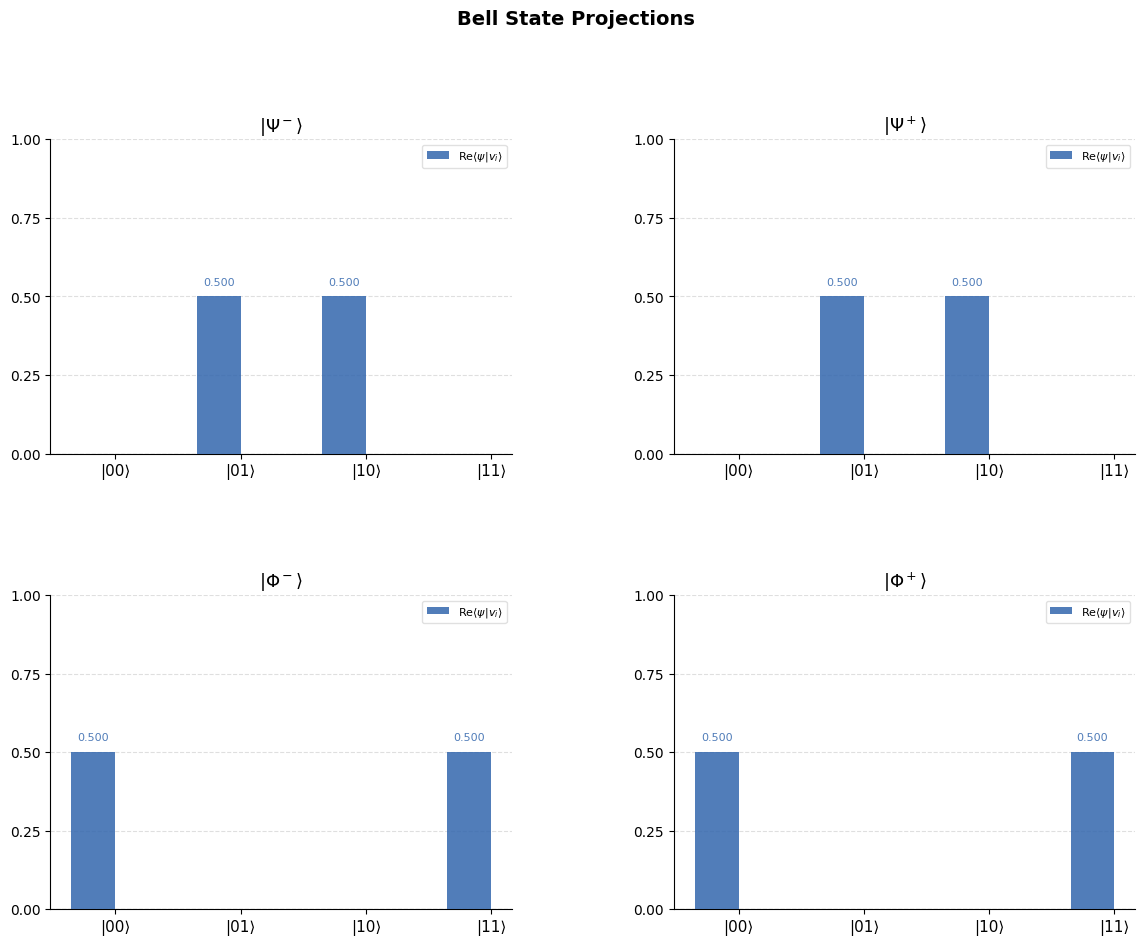

In [27]:
from matplotlib.gridspec import GridSpec

basis_labels = ["|00⟩", "|01⟩", "|10⟩", "|11⟩"]

result_1 = [np.vdot(bellstate_psi_minus, cart_eigvecs[:,-(i+1)]) for i in range(4)]
result_2 = [np.vdot(bellstate_psi_plus,  cart_eigvecs[:,-(i+1)]) for i in range(4)]
result_3 = [np.vdot(bellstate_phi_minus, cart_eigvecs[:,-(i+1)]) for i in range(4)]
result_4 = [np.vdot(bellstate_phi_plus,  cart_eigvecs[:,-(i+1)]) for i in range(4)]

bell_states = [
    (result_1, r"|$\Psi^-\rangle$"),
    (result_2, r"|$\Psi^+\rangle$"),
    (result_3, r"|$\Phi^-\rangle$"),
    (result_4, r"|$\Phi^+\rangle$"),
]

x      = np.arange(len(basis_labels))
width  = 0.35
colors = {"re": "#3266ad", "im": "#d85a30"}

fig = plt.figure(figsize=(14, 10))
fig.suptitle("Bell State Projections", fontsize=14, fontweight="bold", y=1.01)
gs  = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

for idx, (results, label) in enumerate(bell_states):

    row, col = divmod(idx, 2)
    ax = fig.add_subplot(gs[row, col])

    re_vals = [abs(v.real)**2 for v in results]
    im_vals = [abs(v.imag)**2 for v in results]

    bars_re = ax.bar(x - width/2, re_vals, width, label=r"Re$\langle\psi|v_i\rangle$",
                     color=colors["re"], alpha=0.85, zorder=3)
    #bars_im = ax.bar(x + width/2, im_vals, width, label=r"Im$\langle\psi|v_i\rangle$",
    #                 color=colors["im"], alpha=0.85, zorder=3)

    # value labels on bars
    for bar in list(bars_re):
        h = bar.get_height()
        if abs(h) > 1e-3:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + (0.03 if h >= 0 else -0.06),
                f"{h:.3f}",
                ha="center", va="bottom" if h >= 0 else "top",
                fontsize=8, color=bar.get_facecolor()
            )

    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", zorder=2)
    ax.set_title(label, fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels([rf"$v_{i+1}$" for i in range(4)], fontsize=11)
    ax.set_xticklabels(basis_labels, fontsize=11)
    ax.set_ylim(0, 1.0)
    ax.set_yticks(np.linspace(0, 1.0, 5))
    ax.legend(fontsize=8, loc="upper right", framealpha=0.6)
    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=1)
    ax.spines[["top", "right"]].set_visible(False)

#plt.tight_layout()
#plt.savefig("bell_state_projections.pdf", bbox_inches="tight", dpi=150)
plt.show()

In [15]:
nsamples = 1
pdist = np.zeros((nsamples, 4), dtype=complex)
for i in range(nsamples):
    #Create QL-resources -- QL-bits, Cartesian Products
    qlbit_1 = qldit(cfg.n, cfg.k, cfg.l, cfg.d, cfg.coupling, cfg.periodic, cfg.full)
    qlbit_2 = qldit(cfg.n, cfg.k, cfg.lp, cfg.d, cfg.coupling, cfg.periodic, cfg.full)
    qlbit1_qlbit2 = cart_qldit(qlbit_1,qlbit_2)

    #eigenstates of the composite system
    cart_eigvals, cart_eigvecs = np.linalg.eigh(qlbit1_qlbit2)

    bellstate_psi_plus = bell_state(cfg, cart_eigvecs[:,-1], kind="psi_plus")
    for j in range(4): 
        pdist[i,j] = np.vdot(bellstate_psi_plus, cart_eigvecs[:,-(j+1)])

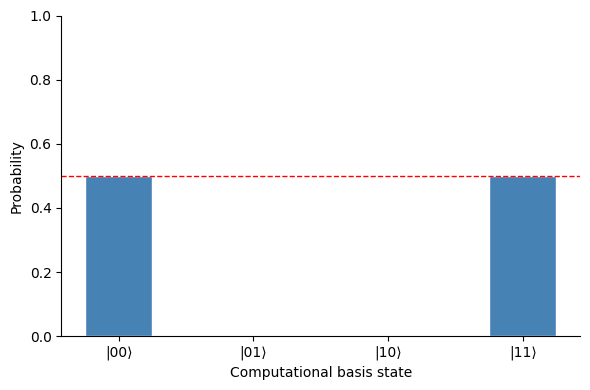

In [ ]:
basis_labels = ["|00⟩", "|01⟩", "|10⟩", "|11⟩"]
data = np.abs(pdist)**2   # shape (100, 4)
# average probability across all 100 rows for each basis state
mean_probs = data.mean(axis=0)   # shape (4,)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(basis_labels, mean_probs, color="steelblue", edgecolor="white", width=0.5)
ax.set_xlabel("Computational basis state")
ax.set_ylabel("Probability")
ax.set_ylim(0, 1)
ax.spines[["top", "right"]].set_visible(False)
ax.axhline(y=0.5, color="red", linestyle="--", linewidth=1, label="uniform (1/4)")

plt.tight_layout()
plt.show()

Generating the Bell States using qubits

In [3]:
from qlgates.cldyn import bell_state_qubit, bell_state_qubitrl
from qlgates.helpers import computational_basis_state

In [5]:
psi0 = computational_basis_state(cfg.NQL, 0)
bellstate_phi_plus_qubit = bell_state_qubit(Config,psi0,kind="phi_plus")
bellstate_phi_minus_qubit = bell_state_qubit(Config,psi0,kind="phi_minus")
bellstate_psi_plus_qubit = bell_state_qubit(Config,psi0,kind="psi_plus")
bellstate_psi_minus_qubit = bell_state_qubit(Config,psi0,kind="psi_minus")

In [7]:
for i in range(4):
    print(np.vdot(bellstate_phi_plus_qubit, computational_basis_state(cfg.NQL, i)))

(0.7071067811865475+0j)
0j
0j
(0.7071067811865475+0j)


In [8]:
for i in range(4):
    print(np.vdot(bellstate_phi_minus_qubit, computational_basis_state(cfg.NQL, i)))

(0.7071067811865475+0j)
0j
0j
(-0.7071067811865475+0j)


In [9]:
for i in range(4):
    print(np.vdot(bellstate_psi_plus_qubit, computational_basis_state(cfg.NQL, i)))

0j
(0.7071067811865475+0j)
(0.7071067811865475+0j)
0j


In [10]:
for i in range(4):
    print(np.vdot(bellstate_psi_minus_qubit, computational_basis_state(cfg.NQL, i)))

0j
(-0.7071067811865475+0j)
(0.7071067811865475+0j)
0j


In [6]:
bellstate_phi_plus_qubitrl = bell_state_qubitrl(Config,psi0,kind="phi_plus")
bellstate_phi_minus_qubitrl = bell_state_qubitrl(Config,psi0,kind="phi_minus")
bellstate_psi_plus_qubitrl = bell_state_qubitrl(Config,psi0,kind="psi_plus")
bellstate_psi_minus_qubitrl = bell_state_qubitrl(Config,psi0,kind="psi_minus")

In [7]:
for i in range(4):
    print(np.vdot(bellstate_phi_plus_qubitrl, computational_basis_state(cfg.NQL, i)))

(0.7071067811865475+0j)
0j
0j
(0.7071067811865475+0j)


In [8]:
for i in range(4):
    print(np.vdot(bellstate_phi_minus_qubitrl, computational_basis_state(cfg.NQL, i)))

(0.7071067811865475+0j)
0j
0j
(-0.7071067811865475+0j)


In [9]:
for i in range(4):
    print(np.vdot(bellstate_psi_plus_qubitrl, computational_basis_state(cfg.NQL, i)))

0j
(0.7071067811865475+0j)
(0.7071067811865475+0j)
0j


In [10]:
for i in range(4):
    print(np.vdot(bellstate_psi_minus_qubitrl, computational_basis_state(cfg.NQL, i)))

0j
(0.7071067811865475+0j)
(-0.7071067811865475+0j)
0j
